# Part II - Ford GoBike System Data Exploration
## by Gundra Yaswanth Kumar Reddy

## Investigation Overview

The goal of this presentation is to communicate the key findings from the exploratory analysis of the Ford GoBike dataset. The presentation focuses on understanding trip duration patterns, identifying the most active user groups, and examining how rider characteristics influence trip duration.

The main findings are:

- Most Ford GoBike trips last less than 20 minutes.
- Subscribers account for nearly 90% of all trips.
- Customers typically take longer trips than subscribers.


## Dataset Overview and Executive Summary

The Ford GoBike dataset contains information about 183,412 bike-sharing trips made in the San Francisco Bay Area during February 2019. The dataset includes trip duration, user type, gender, rider birth year, station information, and trip timestamps.

Key findings from the analysis include:

- Most Ford GoBike trips last less than 20 minutes.
- Subscribers account for nearly 90% of all trips.
- Customers generally take longer trips than subscribers.

In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# suppress warnings from final output
import warnings
warnings.simplefilter("ignore")

# load in the dataset into a pandas dataframe
df = pd.read_csv('201902-fordgobike-tripdata.csv')

# Make a copy of the dataset
bike = df.copy()

# Convert start and end times to datetime format
bike['start_time'] = pd.to_datetime(bike['start_time'])
bike['end_time'] = pd.to_datetime(bike['end_time'])

# Create age column
bike['member_age'] = 2019 - bike['member_birth_year']

# Create trip duration in minutes
bike['duration_min'] = bike['duration_sec'] / 60

## Trip Duration Distribution

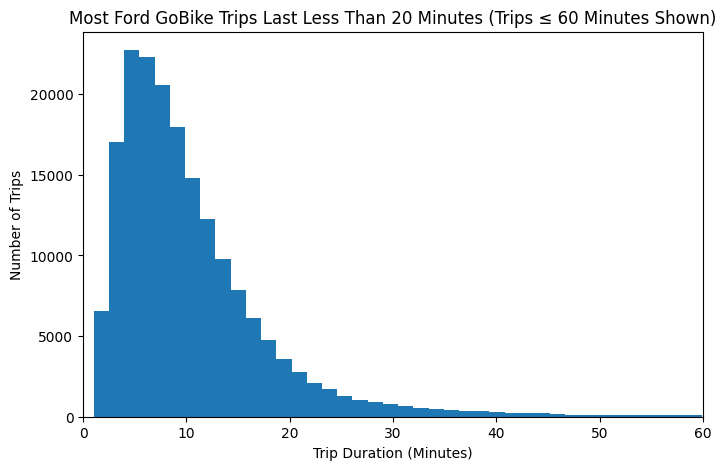

In [2]:
# Focus on trips of 60 minutes or less
common_trips = bike[bike['duration_min'] <= 60]

plt.figure(figsize=(8,5))

plt.hist(common_trips['duration_min'], bins=40)

plt.title('Most Ford GoBike Trips Last Less Than 20 Minutes (Trips ≤ 60 Minutes Shown)')
plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Number of Trips')

plt.xlim(0, 60)

plt.show()

### Observation

Most Ford GoBike trips are completed within 20 minutes, indicating that the bike-sharing system is primarily used for short-distance travel. Trips longer than 60 minutes are excluded from this visualization to improve readability because they represent only a small percentage of all trips.

## Trips by User Type

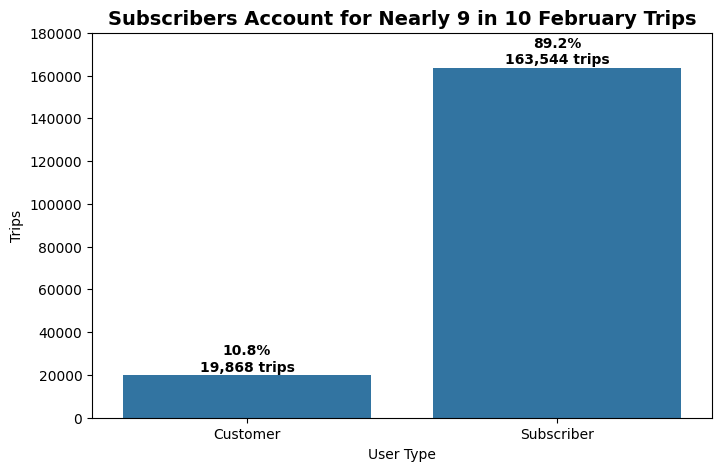

In [3]:
# Calculate counts and percentages
counts = bike['user_type'].value_counts()
total = len(bike)

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=bike,
    x='user_type',
    order=['Customer', 'Subscriber']
)

plt.title(
    'Subscribers Account for Nearly 9 in 10 February Trips',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('User Type')
plt.ylabel('Trips')

# Add labels to each bar
for i, user in enumerate(['Customer', 'Subscriber']):
    count = counts[user]
    percent = (count / total) * 100

    ax.text(
        i,
        count + 2000,
        f'{percent:.1f}%\n{count:,} trips',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Add extra space above the tallest bar
plt.ylim(0, 180000)

plt.show()

### Observation

Subscribers account for nearly 90% of all trips, indicating that the Ford GoBike system is primarily used by regular members. Customers represent a much smaller share of total trips.

## Trip Duration by User Type

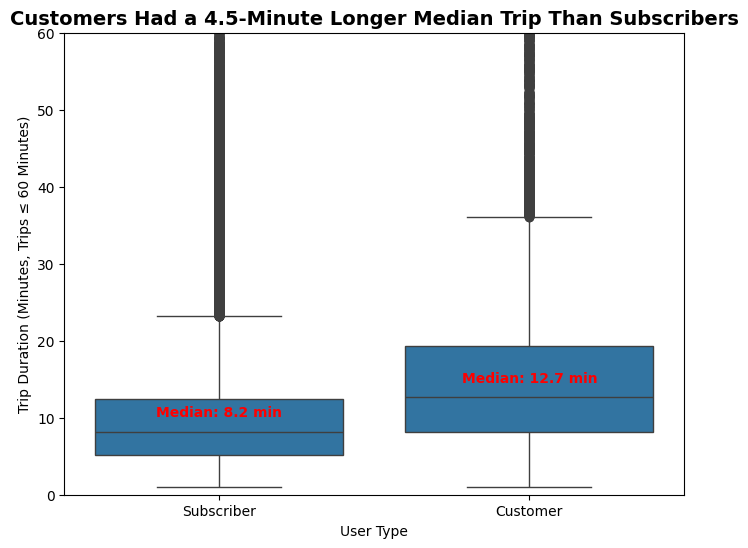

In [4]:
plt.figure(figsize=(8,6))

# Keep only trips up to 60 minutes
common_trips = bike[bike['duration_min'] <= 60]

ax = sns.boxplot(
    data=common_trips,
    x='user_type',
    y='duration_min',
    order=['Subscriber', 'Customer']
)

plt.title(
    'Customers Had a 4.5-Minute Longer Median Trip Than Subscribers',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('User Type')
plt.ylabel('Trip Duration (Minutes, Trips ≤ 60 Minutes)')

# Calculate medians
medians = common_trips.groupby('user_type')['duration_min'].median()

# Add median labels
for i, user in enumerate(['Subscriber', 'Customer']):
    median = medians[user]
    ax.text(
        i,
        median + 2,
        f'Median: {median:.1f} min',
        ha='center',
        color='red',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(0, 60)

plt.show()

### Observation

Customers have a median trip duration of approximately 12.7 minutes, compared with 8.2 minutes for subscribers, indicating that customers generally take longer rides than subscribers. Focusing on trips of 60 minutes or less makes the typical riding behavior easier to compare while reducing the impact of a small number of unusually long trips.

## Final Takeaway

The analysis shows that most Ford GoBike trips are short and are completed within 20 minutes. Subscribers account for nearly 90% of all trips and generally take shorter, more consistent trips than customers. Although customers make far fewer trips, they tend to ride for longer durations, suggesting that subscribers primarily use the service for regular commuting, while customers are more likely to take longer leisure rides.